In [1]:
import os
import sys
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'src'))

from pathlib import Path
import cv2
import pickle
import numpy as np
import matplotlib.pyplot as plt
import math
plt.rcParams["figure.figsize"] = (24,18)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import detection
import torchvision.transforms as transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
data_path = os.path.join(os.path.dirname(os.getcwd()), 'data')

In [3]:
classes = open(os.path.join(data_path, 'labels.txt'), "r").read().split("\n")[:-1]
colors = np.random.uniform(0, 255, size=(len(classes), 3))

In [4]:
# Model
model = detection.fasterrcnn_resnet50_fpn_v2(pretrained=True, progress=True, pretrained_backbone=True).to(device)
model.roi_heads.box_predictor.cls_score = nn.Linear(1024, len(classes), bias=True)

model.to(device).eval()

/home/khoa-ys/Projects/venv_for_projects/football_analysis_venv/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/khoa-ys/Projects/venv_for_projects/football_analysis_venv/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_V2_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/home/khoa-ys/Projects/venv_for_projects/football_analysis_venv/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained_backbone' is deprecated since 0.13 and may be removed in the future, please us

  0%|          | 0.00/167M [00:00<?, ?B/s]

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       

True


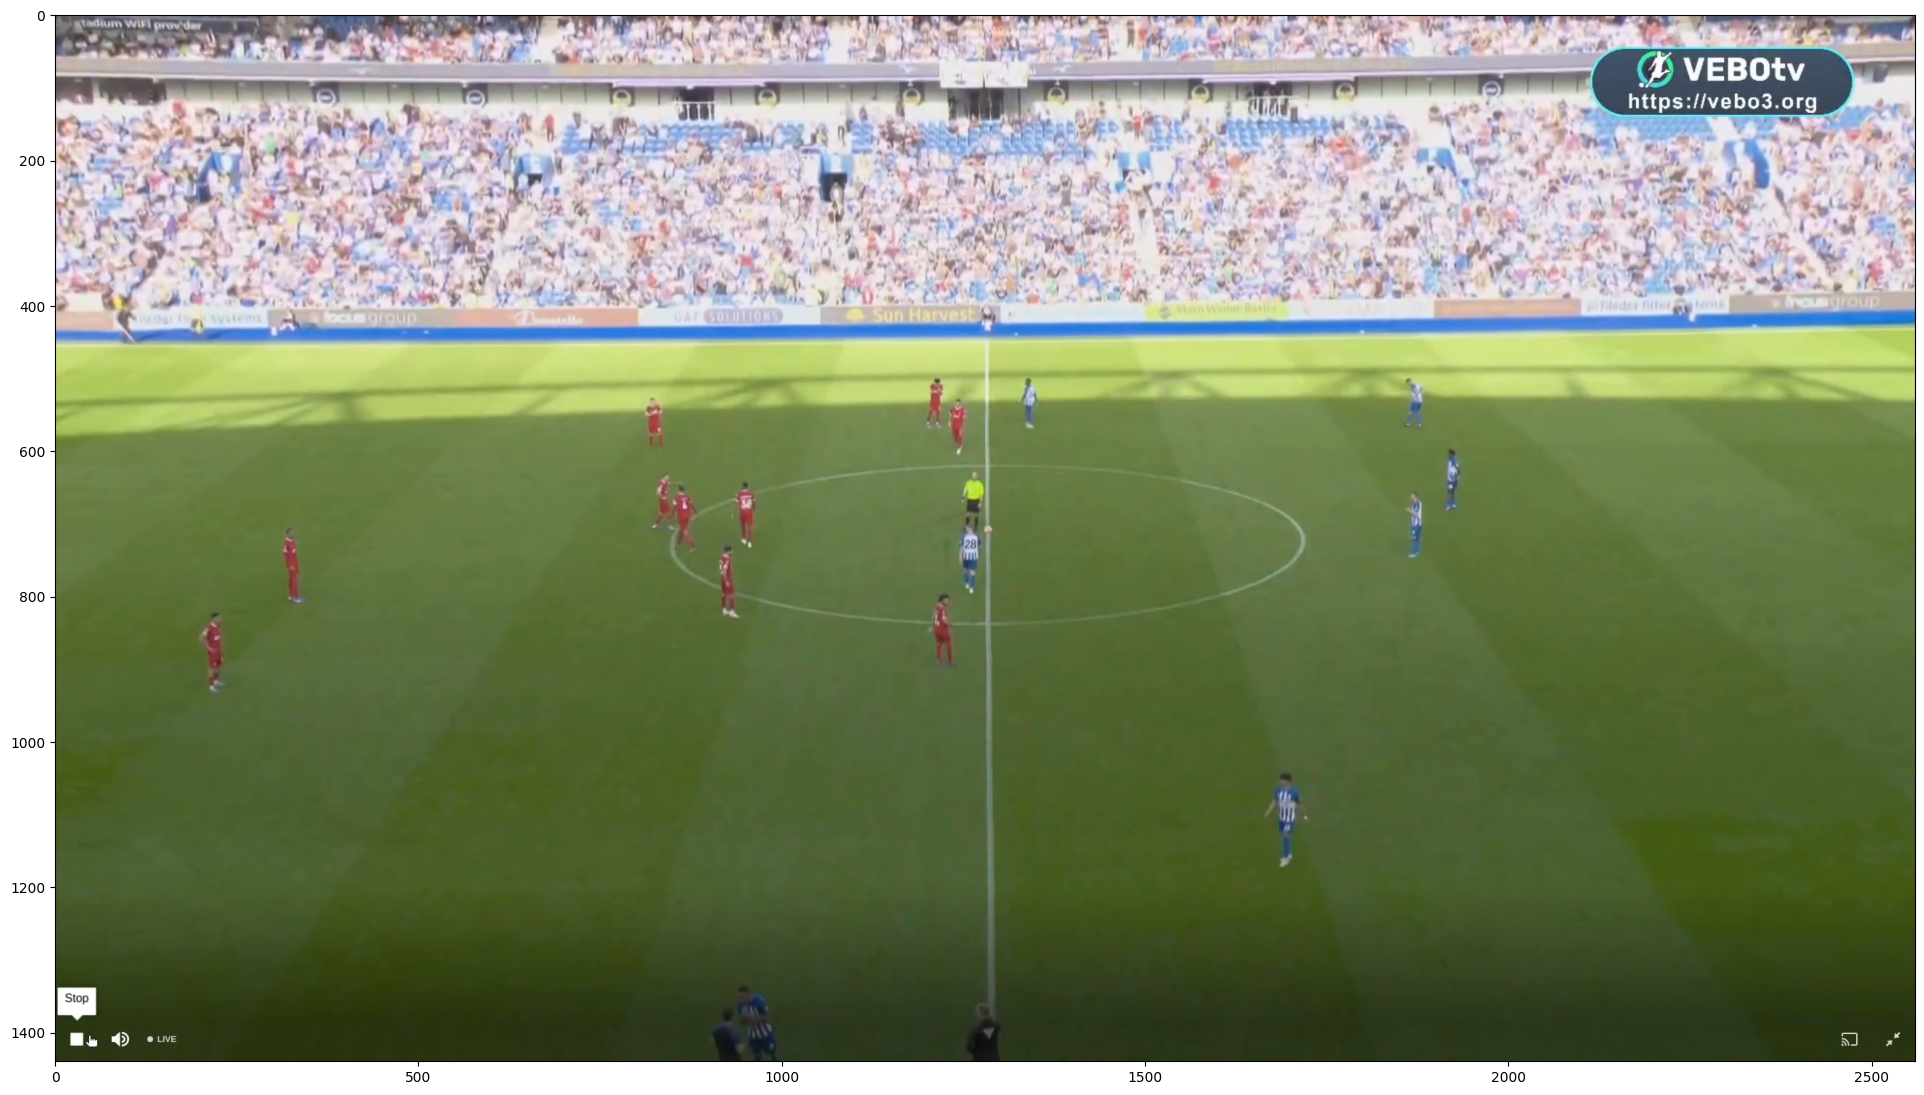

In [5]:
vid_name =  'Liv-BHA 2nd half'
images_path = os.path.join(data_path, 'images' + '/' + vid_name)
print(os.path.exists(images_path))
images_path
image_path = os.path.join(images_path, '000000000015.png')

rgb_image = cv2.imread(image_path, cv2.COLOR_BGR2RGB)

plt.figure()
plt.imshow(rgb_image[:,:,::-1])

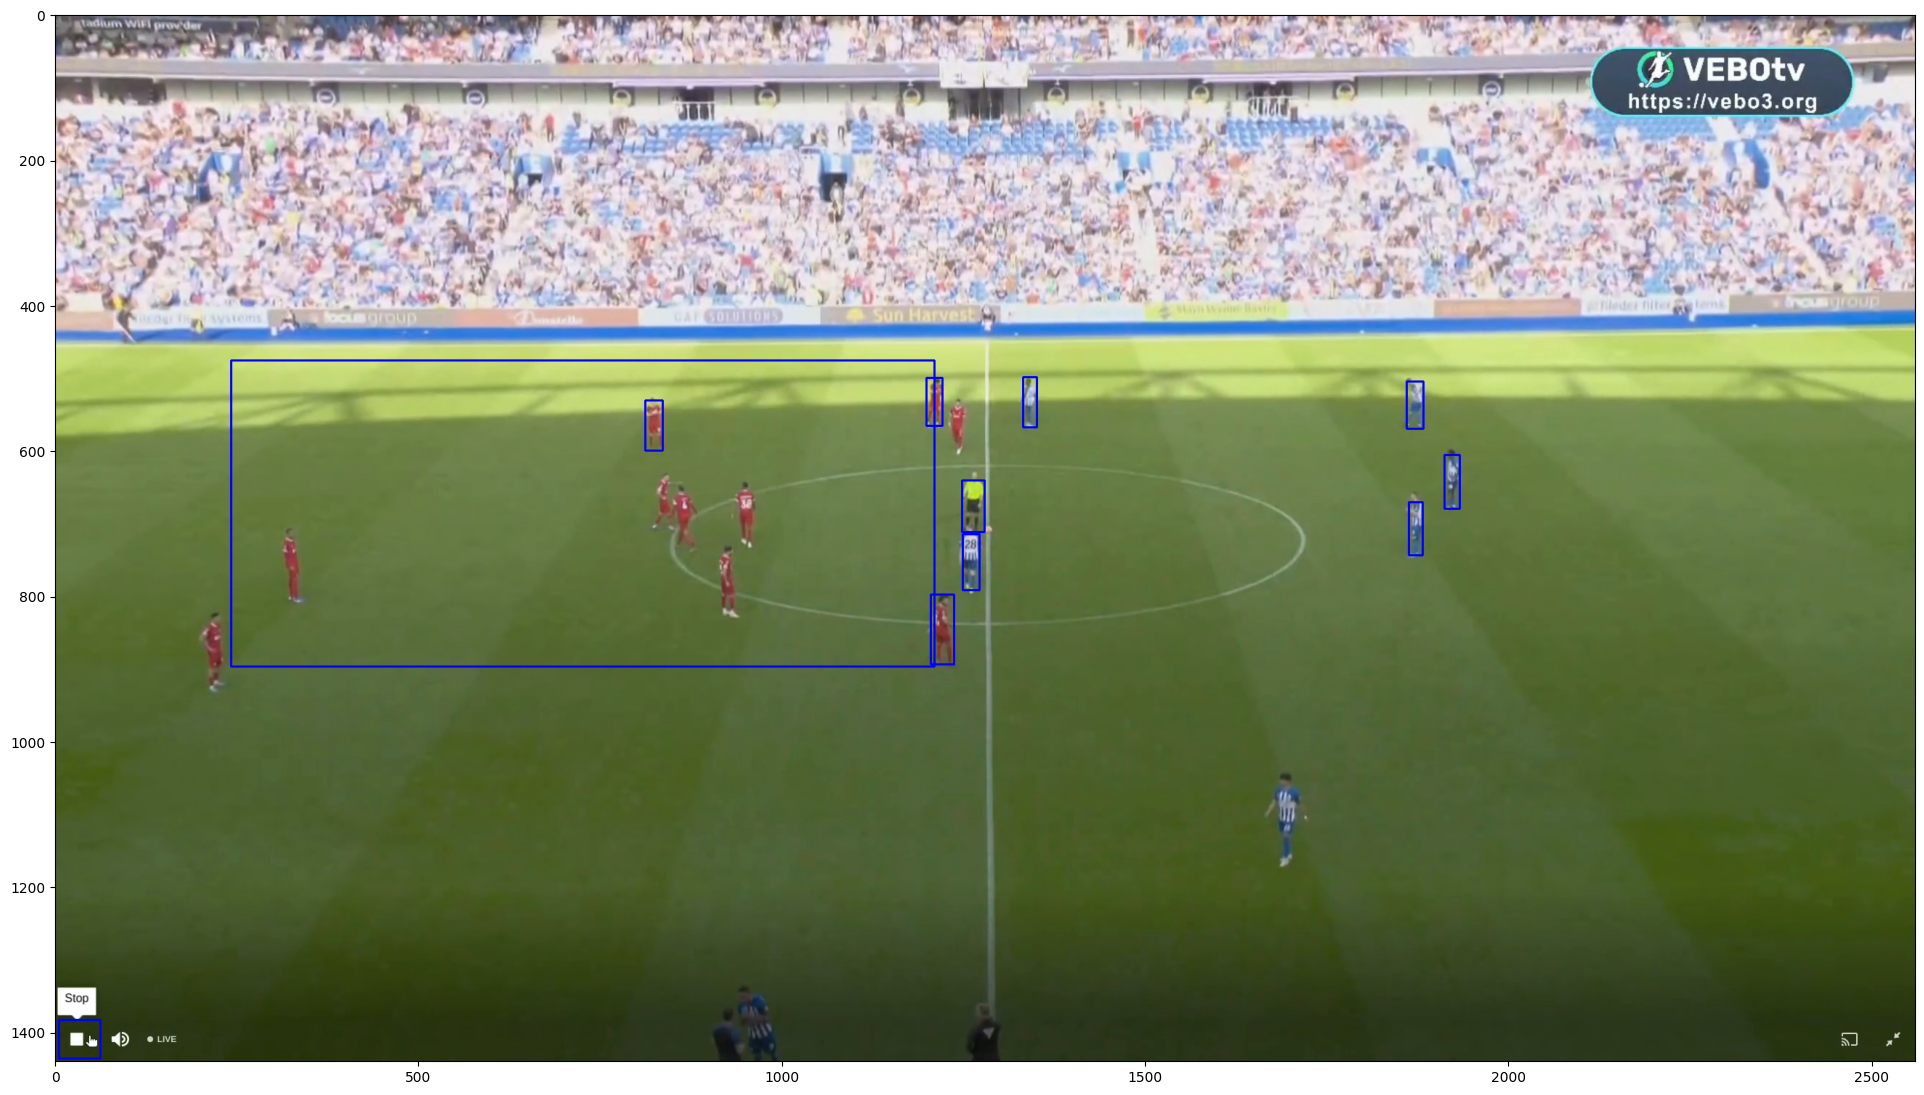

In [6]:
transform = transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))])
outputs = model(transform(rgb_image).unsqueeze(0).to(device))
for output in outputs:
    boxes = output['boxes']
    for box in boxes:
        (startX, startY, endX, endY) = box.int().tolist()
        cv2.rectangle(rgb_image, (startX, startY), (endX, endY),
    				(255, 0, 0), 2)

plt.figure()
plt.imshow(rgb_image[:,:,::-1])